# 09 · E1e: a null-calibrated decision rule, and recovery rates

**Why this notebook.** Notebook 08 showed that the two E1 rules are miscalibrated for the effects at stake:

* the deeper mechanisms add only **0.008–0.019 FEVE** over L1 in synthetic worms;
* the **sufficiency rule** (a deeper rung must not add ≥ 5%) is far too lenient, so it settles on a shallower rung;
* the **necessity rule** (gain > 0) is too strict in the other direction: with precise data a +0.002 gain counts as "needed", which can even invert the bracket.

**Rule v4 (one rule, one threshold).** A rung is *needed* if the lower 95% bootstrap bound of its gain over every shallower rung exceeds **δ**. The closed level is the deepest needed rung.

**Calibrating δ against a null.** δ is set from **null worms**: synthetic worms whose true rung is L1, so every deeper rung is truly unnecessary. For each null worm, the spurious-depth statistic is the largest lower bound of any deeper rung's gain; δ is the largest statistic observed (never below 0). δ is calibrated **separately for each experimental design**, because more precise data produce smaller spurious gains.

**Then, on separate test worms** (different seeds; truths L1, L2, L3), we measure:
* how often the calibrated rule recovers the true rung exactly;
* how often it goes too deep;
* whether the 5-s pulse (`long`) beats `repeat` once the rule is fair.

Test worms with seed 1 are identical to Notebook 08's, so their fits load from its checkpoints.

In [1]:
#@title Setup — run first (works locally on a Mac/PC and on Colab)
import os, sys, subprocess
REPO_URL   = "https://github.com/aslansd/Closure-Bench.git"  # Colab only: clone from here
DRIVE_PATH = "/content/drive/MyDrive/Closure-Bench"          # Colab only: ...or use a Drive copy
IN_COLAB = "google.colab" in sys.modules

def _find_package():
    # 1) explicit location, 2) the repo this notebook lives in, 3) Colab clone / Drive
    cands = [os.environ.get("CLOSUREBENCH_ROOT", ""), ".", "..", "/content/Closure-Bench", DRIVE_PATH]
    for root in cands:
        if root and os.path.isdir(os.path.join(root, "closurebench")):
            return os.path.abspath(root)
    if IN_COLAB:
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", "wormneuroatlas", "optax"], check=False)
        if subprocess.run(["git", "clone", "-q", REPO_URL, "/content/Closure-Bench"]).returncode == 0:
            return "/content/Closure-Bench"
        from google.colab import drive
        drive.mount("/content/drive")
        if os.path.isdir(os.path.join(DRIVE_PATH, "closurebench")):
            return DRIVE_PATH
    raise RuntimeError("closurebench not found. Locally: open this notebook from Closure-Bench/notebooks/, "
                       "or set the environment variable CLOSUREBENCH_ROOT to the Closure-Bench folder.")

ROOT = _find_package()
sys.path.insert(0, ROOT)
try:
    import jax, optax, wormneuroatlas  # noqa: F401
except ImportError as e:
    raise ImportError(f"{e}. Locally, create the environment first: see README.md "
                      "('Run locally'), then select the 'Python (closurebench)' kernel.") from None
RESULTS = os.environ.get("CLOSUREBENCH_RESULTS", os.path.join(ROOT, "results"))
os.makedirs(RESULTS, exist_ok=True)
from closurebench import config as CBC
MODE = CBC.get_mode()        # 'smoke' | 'laptop' | 'full'  (env CLOSUREBENCH_MODE, default: full on GPU, laptop on CPU)
print("closurebench:", ROOT); print("results:", RESULTS); print(CBC.describe_machine()); print("MODE:", MODE)

closurebench: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac
results: /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results
Darwin arm64 | python 3.11.5 | jax 0.10.2 on cpu (cpu) | CPU cores: 8
MODE: laptop


In [2]:
import json, time, datetime, numpy as np, matplotlib.pyplot as plt, jax
import closurebench
assert tuple(int(x) for x in closurebench.__version__.split(".")[:2]) >= (0, 8), \
    f"Notebook 09 needs closurebench >= 0.8 (found {closurebench.__version__}); copy the full package and restart the kernel"
from closurebench import data as D, ladder as lad, metrics as M, design as DZ
plt.rcParams.update({"figure.dpi": 110, "axes.spines.top": False, "axes.spines.right": False})
CONF = {   # template, K, STEPS and noise construction match Notebook 08 so its fits are reused
    "smoke":  dict(N_NEURONS=16,  REAL_WIRING=False, CAL_SEEDS=[11], TEST_TRUTHS=["L1", "L2"], TEST_SEEDS=[1],
                   DESIGNS=["repeat", "long"], K=2, STEPS=15, N_BOOT=100),
    "laptop": dict(N_NEURONS=60,  REAL_WIRING=True,  CAL_SEEDS=[11, 12, 13], TEST_TRUTHS=["L1", "L2", "L3"], TEST_SEEDS=[1, 2],
                   DESIGNS=["repeat", "long"], K=3, STEPS=250, N_BOOT=1000),
    "full":   dict(N_NEURONS=120, REAL_WIRING=True,  CAL_SEEDS=[11, 12, 13, 14, 15], TEST_TRUTHS=["L1", "L2", "L3", "L4"],
                   TEST_SEEDS=[1, 2, 3], DESIGNS=["repeat", "long"], K=5, STEPS=500, N_BOOT=2000),
}[MODE]
globals().update(CONF)
TRIALS, PEPTIDE_SCALE = 3, 0.5
LADDER = ["L0", "L1", "L2", "L3", "L4"]
ORDER = {L: i for i, L in enumerate(LADDER)}
TAG = "" if MODE == "full" else f"_{MODE}"
cfg = lad.SimConfig()
ds_path = os.path.join(RESULTS, "atlas_dataset.npz")
real = D.Dataset.load(ds_path) if os.path.exists(ds_path) else D.load_atlas_dataset()
if REAL_WIRING:
    mk = real.mask()[0]; score = mk.sum(1).astype(float); score[real.stim] += mk.sum(0)
    template = D.subset(real, np.sort(np.argsort(-score)[:N_NEURONS]))
else:
    template = lad.random_wiring(N=N_NEURONS, seed=0, trials=4)

def worm(truth, seed, kind):
    """Atlas + `kind` design, recorded from a synthetic worm (identical construction to Notebook 08)."""
    base, _, _ = lad.make_synthetic(template, true_level=truth, seed=seed, peptide_scale=PEPTIDE_SCALE)
    C = DZ.combine(template, DZ.design_columns(template, kind, trials=TRIALS))
    ds, _, _ = lad.make_synthetic(C, true_level=truth, seed=seed, peptide_scale=PEPTIDE_SCALE, noise_sd=base.meta["noise_sd"])
    return ds

def analyse(truth, seed, kind):
    """Cross-validated ladder + bootstrap for one worm; checkpointed (shares Notebook 08's checkpoint folder)."""
    ds = worm(truth, seed, kind)
    ck = os.path.join(RESULTS, "e1d_validation_ck", MODE, f"{truth}_s{seed}_{kind}")
    reused = os.path.isdir(ck) and len(os.listdir(ck)) > 0
    preds, _, _ = M.run_crossvalidated_ladder(ds, levels=LADDER, k=K, steps=STEPS, lr=2e-2, cfg=cfg,
                                              equal_budget=True, restarts=3, checkpoint=ck, log=None)
    pt, bt = M.bootstrap_feve(preds, ds, LADDER, n_boot=N_BOOT)
    return dict(point=pt, boots=bt, reused=reused)

n_runs = len(DESIGNS) * (len(CAL_SEEDS) + len(TEST_TRUTHS) * len(TEST_SEEDS))
print(template.summary()); print(f"{n_runs} worms in total (some may load from Notebook 08's checkpoints)")

Dataset: N=60 neurons, S=60 stimulated neurons, strains=('wt', 'unc31')
  chemical synapses: 286  gap-junction pairs: 98  peptidergic pairs: 2214
  signs: +49 / -51 / unknown 186 (on existing synapses)
  wt: 3534 observed pairs, median trials 10
  unc31: 2401 observed pairs, median trials 2
18 worms in total (some may load from Notebook 08's checkpoints)


### Pre-registration (before §1)

Recorded in `results/E1e_preregistration*.json`:

* **Calibration:** δ_design = the largest spurious-depth statistic over the null worms (truth L1, seeds `CAL_SEEDS`), floor 0.
* **The rule is valid for a design** if, on the test worms, it never picks a rung deeper than the truth.
* **The rule is useful for a design** if it is valid and recovers L2 or L3 exactly in at least one test worm.
* **`long` beats `repeat`** if it has more exact hits on the L2/L3 test worms, with neither design invalid.

In [3]:
prereg = os.path.join(RESULTS, f"E1e_preregistration{TAG}.json")
plan = {"experiment": "E1e null-calibrated decision rule (synthetic)", "mode": MODE,
        "registered_at": datetime.datetime.now(datetime.timezone.utc).isoformat(), "config": CONF,
        "rule": "v4: rung needed if lower 95% CI bound of gain over best shallower rung > delta_design; closed = deepest needed",
        "calibration": "delta_design = max over null worms (truth L1, CAL_SEEDS) of max lower bound of any deeper rung's gain; floor 0",
        "valid": "on test worms, never deeper than the truth", "useful": "valid and >= 1 exact hit on L2/L3 test worms",
        "comparison": "long beats repeat if more exact hits on L2/L3 test worms and both valid"}
if os.path.exists(prereg):
    plan = json.load(open(prereg)); print("Existing registration (", plan["registered_at"], ") used unchanged.")
else:
    json.dump(plan, open(prereg, "w"), indent=2); print("Registered ->", prereg)

Registered -> /Users/asataryd/Documents/ENI-Projects/Aslan/NeuroAILab/Githubs/Closure-Bench-Mac/results/E1e_preregistration_laptop.json


## 1 · Calibrating δ on null worms

Each null worm has true rung L1. Its spurious-depth statistic is the largest lower bound of the gain of L2, L3 or L4 over every shallower rung. A well-calibrated δ must exceed these statistics.

In [4]:
null = {k: [] for k in DESIGNS}
for kind in DESIGNS:
    for seed in CAL_SEEDS:
        t0 = time.time(); r = analyse("L1", seed, kind)
        s = M.null_statistic(r["boots"], "L1", tuple(LADDER)); null[kind].append(s)
        print(f"null worm seed {seed} + {kind:6s}: spurious-depth statistic {s:+.4f}   "
              f"FEVE " + " ".join(f"{L}={r['point'][L]:.3f}" for L in LADDER) + f"  ({(time.time() - t0) / 60:.0f} min)")
DELTA = {k: M.calibrate_delta(null[k]) for k in DESIGNS}
print("\ncalibrated delta per design:", {k: round(v, 4) for k, v in DELTA.items()})

null worm seed 11 + repeat: spurious-depth statistic -0.4816   FEVE L0=0.462 L1=0.585 L2=0.595 L3=0.621 L4=0.582  (17 min)
null worm seed 12 + repeat: spurious-depth statistic -0.0001   FEVE L0=0.688 L1=0.990 L2=0.991 L3=0.992 L4=0.992  (17 min)
null worm seed 13 + repeat: spurious-depth statistic -0.0002   FEVE L0=0.757 L1=0.986 L2=0.986 L3=0.986 L4=0.986  (18 min)
null worm seed 11 + long  : spurious-depth statistic +0.0025   FEVE L0=0.591 L1=0.962 L2=0.969 L3=0.970 L4=0.969  (18 min)
null worm seed 12 + long  : spurious-depth statistic +0.0026   FEVE L0=0.604 L1=0.976 L2=0.982 L3=0.985 L4=0.985  (17 min)
null worm seed 13 + long  : spurious-depth statistic +0.0015   FEVE L0=0.471 L1=0.981 L2=0.985 L3=0.987 L4=0.987  (17 min)

calibrated delta per design: {'repeat': 0.0, 'long': 0.0026}


## 2 · Recovery on test worms

The calibrated rule is applied with each design's own δ. The old pair of rules is shown alongside for comparison.

In [5]:
test = {}
for truth in TEST_TRUTHS:
    for seed in TEST_SEEDS:
        for kind in DESIGNS:
            t0 = time.time(); r = analyse(truth, seed, kind)
            v4 = M.calibrated_closure(r["boots"], DELTA[kind], tuple(LADDER))
            old_suff = M.closure_decision(r["point"], r["boots"], ladder=tuple(LADDER), blackbox=None)["L_star"]
            old_nec = M.necessity(r["point"], r["boots"], ladder=tuple(LADDER))["L_needed"]
            test[(truth, seed, kind)] = dict(L_closed=v4["L_closed"], lower_bounds=v4["lower_bounds"], point=r["point"],
                                             old_L_star=old_suff, old_L_needed=old_nec)
            mark = "✓" if v4["L_closed"] == truth else ("too deep" if ORDER[v4["L_closed"]] > ORDER[truth] else "too shallow")
            print(f"truth {truth} seed {seed} + {kind:6s}: v4 closed = {v4['L_closed']} ({mark});  old rules L*={old_suff}, "
                  f"L_needed={old_nec}   [{'reused' if r['reused'] else f'{(time.time() - t0) / 60:.0f} min'}]")

truth L1 seed 1 + repeat: v4 closed = L2 (too deep);  old rules L*=L1, L_needed=L2   [16 min]
truth L1 seed 1 + long  : v4 closed = L2 (too deep);  old rules L*=L1, L_needed=L3   [16 min]
truth L1 seed 2 + repeat: v4 closed = L2 (too deep);  old rules L*=L1, L_needed=L2   [16 min]
truth L1 seed 2 + long  : v4 closed = L1 (✓);  old rules L*=L1, L_needed=L3   [17 min]
truth L2 seed 1 + repeat: v4 closed = L3 (too deep);  old rules L*=L1, L_needed=L3   [reused]
truth L2 seed 1 + long  : v4 closed = L2 (✓);  old rules L*=L1, L_needed=L2   [reused]
truth L2 seed 2 + repeat: v4 closed = L2 (✓);  old rules L*=L1, L_needed=L2   [17 min]
truth L2 seed 2 + long  : v4 closed = L1 (too shallow);  old rules L*=L1, L_needed=L2   [17 min]
truth L3 seed 1 + repeat: v4 closed = L3 (✓);  old rules L*=L2, L_needed=L3   [reused]
truth L3 seed 1 + long  : v4 closed = L1 (too shallow);  old rules L*=L3, L_needed=L2   [reused]
truth L3 seed 2 + repeat: v4 closed = L1 (too shallow);  old rules L*=L3, L_needed

repeat: delta 0.0000 | exact 2/6 | L2/L3 hits 2/4 (old rules: 0) | too deep 3 -> valid False, useful False
long  : delta 0.0026 | exact 3/6 | L2/L3 hits 2/4 (old rules: 1) | too deep 1 -> valid False, useful False

Registered rule -> long beats repeat: False


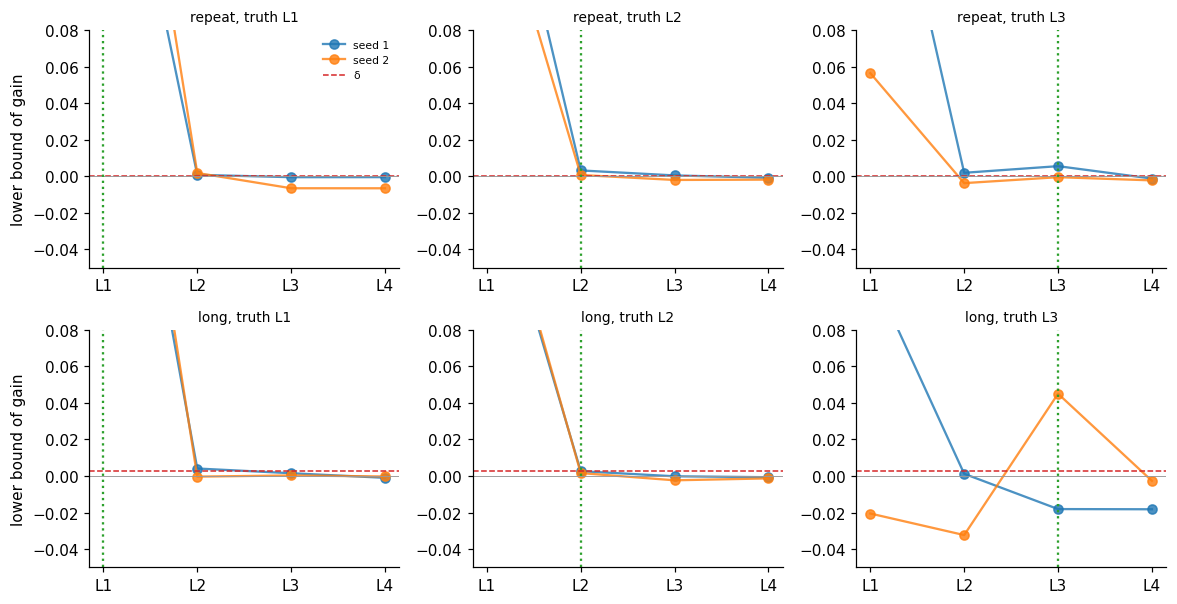

In [6]:
summary = {}
for kind in DESIGNS:
    rows = [(t, s, test[(t, s, kind)]) for t in TEST_TRUTHS for s in TEST_SEEDS]
    deep = [(t, s, r) for t, s, r in rows if t != "L1"]
    summary[kind] = dict(delta=DELTA[kind],
                         too_deep=sum(ORDER[r["L_closed"]] > ORDER[t] for t, s, r in rows),
                         exact=sum(r["L_closed"] == t for t, s, r in rows), n=len(rows),
                         deep_hits=sum(r["L_closed"] == t for t, s, r in deep), n_deep=len(deep),
                         old_both_hits=sum(r["old_L_star"] == t and r["old_L_needed"] == t for t, s, r in deep))
    summary[kind]["valid"] = summary[kind]["too_deep"] == 0
    summary[kind]["useful"] = summary[kind]["valid"] and summary[kind]["deep_hits"] >= 1
for kind, s in summary.items():
    print(f"{kind:6s}: delta {s['delta']:.4f} | exact {s['exact']}/{s['n']} | L2/L3 hits {s['deep_hits']}/{s['n_deep']} "
          f"(old rules: {s['old_both_hits']}) | too deep {s['too_deep']} -> valid {s['valid']}, useful {s['useful']}")
long_beats = all(s["valid"] for s in summary.values()) and summary["long"]["deep_hits"] > summary["repeat"]["deep_hits"]
print("\nRegistered rule -> long beats repeat:", long_beats)

fig, axes = plt.subplots(len(DESIGNS), len(TEST_TRUTHS), figsize=(3.6 * len(TEST_TRUTHS), 2.8 * len(DESIGNS)), squeeze=False)
for i, kind in enumerate(DESIGNS):
    for j, truth in enumerate(TEST_TRUTHS):
        ax = axes[i][j]
        for s in TEST_SEEDS:
            lb = test[(truth, s, kind)]["lower_bounds"]
            ax.plot(range(1, 5), [lb[L] for L in LADDER[1:]], "o-", alpha=0.8, label=f"seed {s}")
        ax.axhline(DELTA[kind], c="tab:red", ls="--", lw=1, label="δ"); ax.axhline(0, c="0.6", lw=0.6)
        ax.axvline(ORDER[truth], c="tab:green", ls=":"); ax.set_xticks(range(1, 5)); ax.set_xticklabels(LADDER[1:])
        ax.set_ylim(-0.05, 0.08); ax.set_title(f"{kind}, truth {truth}", fontsize=9)
        if j == 0: ax.set_ylabel("lower bound of gain")
axes[0][0].legend(fontsize=7, frameon=False); plt.tight_layout(); plt.show()

## 3 · Real data under the calibrated rule

This applies rule v4 to Notebook 04's held-out predictions (120 neurons, atlas protocol), with no refitting. One caveat: δ was calibrated on 60-neuron synthetic worms, whose noise and FEVE scale differ from the real data. The result is informative only if it holds **for every δ ≥ 0**, i.e. if no rung's lower bound exceeds 0 in the first place.

In [7]:
real_out = None
e1_path = os.path.join(RESULTS, "E1_result_laptop.json")
if os.path.exists(e1_path) and MODE != "smoke":
    c = json.load(open(os.path.join(RESULTS, json.load(open(e1_path))["preregistration"])))["config"]
    ds_r = real
    if c["n_neurons"] < ds_r.N:
        mk = ds_r.mask()[0]; score = mk.sum(1).astype(float); score[ds_r.stim] += mk.sum(0)
        ds_r = D.subset(ds_r, np.sort(np.argsort(-score)[:c["n_neurons"]]))
    preds_r = dict(np.load(os.path.join(RESULTS, "E1_heldout_predictions_laptop.npz")))
    pt, bt = M.bootstrap_feve(preds_r, ds_r, LADDER, n_boot=2000)
    lb = M.gain_lower_bounds(bt, tuple(LADDER))
    print("lower bound of each rung's gain over the best shallower rung:", {L: round(v, 4) for L, v in lb.items()})
    real_out = {"lower_bounds": lb, "L_closed_delta0": M.calibrated_closure(bt, 0.0, tuple(LADDER))["L_closed"],
                "L_closed_calibrated": {k: M.calibrated_closure(bt, DELTA[k], tuple(LADDER))["L_closed"] for k in DESIGNS}}
    print("closed level with delta = 0:", real_out["L_closed_delta0"], "| with the calibrated deltas:", real_out["L_closed_calibrated"])
else:
    print("skipped (smoke mode or Notebook 04 laptop results missing)")

lower bound of each rung's gain over the best shallower rung: {'L1': -0.0684, 'L2': -0.0563, 'L3': -0.0721, 'L4': -0.0667}
closed level with delta = 0: L0 | with the calibrated deltas: {'repeat': 'L0', 'long': 'L0'}


In [8]:
out = {"delta": DELTA, "null_statistics": null, "summary": summary, "long_beats_repeat": bool(long_beats),
       "test": {f"{t}_s{s}_{k}": {kk: v for kk, v in r.items()} for (t, s, k), r in test.items()}, "real": real_out}
json.dump(out, open(os.path.join(RESULTS, f"E1e_result{TAG}.json"), "w"), indent=2, default=float)
print("saved", f"E1e_result{TAG}.json")

saved E1e_result_laptop.json


### Results of the `laptop` run (2026-10-07; 60-neuron real wiring; 3 null + 6 test worms per design)

**§1 Calibration.** δ_repeat = 0 (both usable null statistics were about −0.0002) and δ_long = 0.0026.

One null fit failed outright: seed 11 + `repeat` has L1 FEVE 0.585, against 0.99 for the other null worms, and a statistic of −0.48. A failed fit pulls δ *down*, so null worms with failed fits should be excluded from calibration.

**§2 Test worms: the calibrated rule is not valid for either design.**

| | `repeat` (δ = 0) | `long` (δ = 0.0026) |
|---|---|---|
| exact recoveries | 2/6 | 3/6 |
| L2/L3 hits | 2/4 | 2/4 |
| too deep | **3** (L1 → L2 twice, L2 → L3) | **1** (L1 → L2) |
| too shallow | 1 | 2 |

Registered verdict: **invalid** for both designs, so the "long beats repeat" comparison is void.

**Why: the L2 gain does not depend on whether L2 is present.** The figure shows the lower bound of the L2 rung's gain:
* in worms whose truth is **L1**, about **+0.001 to +0.004**;
* in worms whose truth is **L2**, about **+0.002 to +0.003**.

Adding adaptation helps a *fitted* model by the same small amount whether or not the worm has it: the extra flexibility partly compensates for the imperfect L1 fit (Notebook 07: fits are not identified). Three null worms do not cover the spread of this spurious gain, so δ was set too low.

The one clear genuine detection is **L3 with the long pulse** (seed 2): gain lower bound +0.045, roughly ten times the spurious level. Peptide-like slow signalling *can* become visible under a long pulse in some worms. Adaptation (L2) cannot be separated from compensation for misfit in any case tested.

**§3 Real data.** No rung's lower bound is above 0 (L1: −0.068, L2: −0.056, L3: −0.072, L4: −0.067). The closed level is **L0 for every δ ≥ 0**, so the real-data conclusion does not depend on calibration.

### Where this leaves E1

Across Notebooks 02 and 06–09, the limits are now mapped:
* On amplitude data from single-neuron stimulation, the real worm is bracketed at **L0 ≤ closed ≤ L1**. This is robust to every rule tried.
* **L2 is not identifiable** from this family of experiments: its gain is indistinguishable from compensation for misfit.
* **L3 can become identifiable** with a long-pulse experiment in some worms.

A further round (more null worms; uncertainty that includes refitting, not only resampling of stimuli) would sharpen these rates but not change the picture. E1 therefore stops here, and the project moves to **E3 (Notebook 10)**, which asks whether the closed level stays fixed over time and needs no identification of deeper rungs.

## 4 · Reading the result

| outcome | consequence |
|---|---|
| v4 valid and useful for `long`, and `long` beats `repeat` | Use rule v4 for all closure decisions. Request the 5-s pulse experiment, and report the recovery rate as the power of a future E1. |
| v4 valid for both designs, but with few L2/L3 hits for either | The rule is now fair, but L2/L3 effects remain below what one added experiment resolves. Increase trials, combine `long` with `train`, or move to spontaneous-activity data. |
| v4 goes too deep on a test worm ← **this run** | δ is under-calibrated, and more fundamentally the spurious L2 gain is as large as the true one (see results above). Depth claims about L2 are not supportable with this family of experiments. |

**For the proposal.** A closure claim needs a calibrated null, just like any detection claim: "level L is closed" should mean "no deeper level beats L by more than deeper-but-absent mechanisms do by chance". Rule v4 makes this explicit and auditable.

> **Follow-up (added 2026-10-08): E1 reopened.** Notebook 18 gave the fitted L1 a slow K⁺-like current in its *substrate*, and on 3/5 folds it predicted held-out data better. Notebook 19 tested this properly: two numbers chosen on training pairs improve cross-validated held-out FEVE by +0.025 [+0.013, +0.039], beyond a gain control and with no false positive on L1-generated data. That is below the 0.05 margin used here, so the closed level does not move. Notebook 20 tried to tell genuine slow adaptation from an under-fitted L1, but failed its own sanity check: the models were not started from the same state, because E1's 30-s burn-in probably does not reach rest. Notebook 21 redid it from the exact resting state: the gain survives (+0.025 [+0.011, +0.041]), half of it needs slow dynamics beyond a rescaled L1, and E1's own predictions are barely affected by the burn-in. Fitted with the same budget as a re-fitted L1, it keeps +0.024 [+0.014, +0.039] (Notebook 22). **Notebook 23 re-applies this notebook's rule v4 (and E1's other two rules) with the new rung on the ladder.**